In [134]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import AdaBoostRegressor
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import GradientBoostingRegressor
from lightgbm import LGBMClassifier
from lightgbm import LGBMRegressor
import time
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import LinearRegression


In [135]:
# Q6 Identify Features and Target Variables

# Load Dataset
df = pd.read_csv("Smart_Outcome_Predictor_Datasetpro5.csv")

# Display Dataset
print("Dataset Shape:", df.shape)

# Classification Target
classification_target = "completion_status"

# Regression Target
regression_target = "final_score"

# Features
features = df.drop(
    columns=[
        "student_id",
        classification_target,
        regression_target
    ]
)

# Display Features and Targets
print("\nFeatures:")
print(features.columns.tolist())

print("\nClassification Target:")
print(classification_target)

print("\nRegression Target:")
print(regression_target)

Dataset Shape: (5200, 19)

Features:
['age', 'country_region', 'device_type', 'education_background', 'course_level', 'course_category', 'course_start_date', 'week_of_year', 'sessions', 'time_spent_hours', 'videos_watched', 'quiz_attempts', 'assignments_submitted', 'forum_posts', 'avg_quiz_score', 'attendance_rate']

Classification Target:
completion_status

Regression Target:
final_score


In [ ]:
# Q7 Train-Test Split

# Load Dataset
df = pd.read_csv("Smart_Outcome_Predictor_Datasetpro5.csv")

# Features
X = df.drop(
    columns=["student_id", "completion_status", "final_score"]
)

# Targets
y_classification = df["completion_status"]
y_regression = df["final_score"]


# Classification Train-Test Split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X,
    y_classification,
    test_size=0.20,
    random_state=42,
    stratify=y_classification
)

print("Classification:")
print("X_train:", X_train_c.shape)
print("X_test :", X_test_c.shape)
print("y_train:", y_train_c.shape)
print("y_test :", y_test_c.shape)

# Regression Train-Test Split
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X,
    y_regression,
    test_size=0.20,
    random_state=42
)

print("\nRegression:")
print("X_train:", X_train_r.shape)
print("X_test :", X_test_r.shape)
print("y_train:", y_train_r.shape)
print("y_test :", y_test_r.shape)

Classification:
X_train: (4160, 16)
X_test : (1040, 16)
y_train: (4160,)
y_test : (1040,)

Regression:
X_train: (4160, 16)
X_test : (1040, 16)
y_train: (4160,)
y_test : (1040,)


In [137]:
# Q8 Data Preprocessing

# Identify Numerical Columns
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()


# Identify Categorical Columns
categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()


print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)


# Numerical Preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])


# Categorical Preprocessing
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ))
])


# Combine Preprocessing
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numerical_columns),
    ("categorical", categorical_pipeline, categorical_columns)
])


print("\nPreprocessing Pipeline Created Successfully!")

Numerical Columns:
['age', 'week_of_year', 'sessions', 'time_spent_hours', 'videos_watched', 'quiz_attempts', 'assignments_submitted', 'forum_posts', 'avg_quiz_score', 'attendance_rate']

Categorical Columns:
['country_region', 'device_type', 'education_background', 'course_level', 'course_category', 'course_start_date']

Preprocessing Pipeline Created Successfully!


In [ ]:
# Q9 Bagging Classifier

bagging_classifier = Pipeline([
    ("preprocessor", preprocessor),
    ("model", BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=42),
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Train Model
bagging_classifier.fit(X_train_c, y_train_c)

# Prediction
y_pred_bagging = bagging_classifier.predict(X_test_c)

# Accuracy
accuracy = accuracy_score(y_test_c, y_pred_bagging)

print("Bagging Classifier Accuracy:", accuracy)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_bagging))

Bagging Classifier Accuracy: 0.7173076923076923

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.81      0.78       650
           1       0.64      0.56      0.60       390

    accuracy                           0.72      1040
   macro avg       0.70      0.69      0.69      1040
weighted avg       0.71      0.72      0.71      1040



In [ ]:
# Q10 Bagging Regressor

# Create Bagging Regressor
bagging_regressor = Pipeline([
    ("preprocessor", preprocessor),
    ("model", BaggingRegressor(
        estimator=DecisionTreeRegressor(random_state=42),
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

# Train Model
bagging_regressor.fit(X_train_r, y_train_r)

# Prediction
y_pred_bagging_reg = bagging_regressor.predict(X_test_r)

# Evaluation
mae = mean_absolute_error(y_test_r, y_pred_bagging_reg)
mse = mean_squared_error(y_test_r, y_pred_bagging_reg)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_bagging_reg)

print("Bagging Regressor")
print("====================")
print("MAE  :", mae)
print("MSE  :", mse)
print("RMSE :", rmse)
print("R2 Score:", r2)

Bagging Regressor
-------------------------
MAE  : 8.00499423076923
MSE  : 100.10411614423076
RMSE : 10.005204452895041
R2 Score: 0.46422420267859954


In [ ]:
# Q11 Compare Bagging Regressor with Single Base Model

# Single Base Model
base_regressor = Pipeline([
    ("preprocessor", preprocessor),
    ("model", DecisionTreeRegressor(random_state=42))
])

# Train Base Model
base_regressor.fit(X_train_r, y_train_r)

# Prediction
y_pred_base = base_regressor.predict(X_test_r)

# Base Model Evaluation
base_mae = mean_absolute_error(y_test_r, y_pred_base)
base_mse = mean_squared_error(y_test_r, y_pred_base)
base_rmse = np.sqrt(base_mse)
base_r2 = r2_score(y_test_r, y_pred_base)


# Bagging Model Evaluation
bagging_mae = mean_absolute_error(y_test_r, y_pred_bagging_reg)
bagging_mse = mean_squared_error(y_test_r, y_pred_bagging_reg)
bagging_rmse = np.sqrt(bagging_mse)
bagging_r2 = r2_score(y_test_r, y_pred_bagging_reg)


print("Model Comparison")
print("==============================")

print("\nSingle Decision Tree Regressor:")
print("MAE  :", base_mae)
print("MSE  :", base_mse)
print("RMSE :", base_rmse)
print("R2 Score:", base_r2)

print("\nBagging Regressor:")
print("MAE  :", bagging_mae)
print("MSE  :", bagging_mse)
print("RMSE :", bagging_rmse)
print("R2 Score:", bagging_r2)

Model Comparison

Single Decision Tree Regressor:
MAE  : 10.55923076923077
MSE  : 177.16948076923077
RMSE : 13.310502649007315
R2 Score: 0.05175607680919725

Bagging Regressor:
MAE  : 8.00499423076923
MSE  : 100.10411614423076
RMSE : 10.005204452895041
R2 Score: 0.46422420267859954


In [ ]:
# Q12 AdaBoost Classifier

# Create AdaBoost Classifier
adaboost_classifier = Pipeline([
    ("preprocessor", preprocessor),
    ("model", AdaBoostClassifier(
        estimator=DecisionTreeClassifier(
            max_depth=1,
            random_state=42
        ),
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    ))
])

# Train Model
adaboost_classifier.fit(X_train_c, y_train_c)

# Prediction
y_pred_adaboost = adaboost_classifier.predict(X_test_c)

# Accuracy
accuracy_adaboost = accuracy_score(
    y_test_c,
    y_pred_adaboost
)

print("AdaBoost Classifier Accuracy:", accuracy_adaboost)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test_c,
        y_pred_adaboost
    )
)

AdaBoost Classifier Accuracy: 0.7365384615384616

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       650
           1       0.69      0.54      0.61       390

    accuracy                           0.74      1040
   macro avg       0.72      0.70      0.70      1040
weighted avg       0.73      0.74      0.73      1040



In [142]:
# Q13 AdaBoost Regressor

# Create AdaBoost Regressor
adaboost_regressor = Pipeline([
    ("preprocessor", preprocessor),
    ("model", AdaBoostRegressor(
        estimator=DecisionTreeRegressor(
            max_depth=1,
            random_state=42
        ),
        n_estimators=100,
        learning_rate=0.5,
        random_state=42
    ))
])

# Train Model
adaboost_regressor.fit(X_train_r, y_train_r)

# Prediction
y_pred_adaboost_reg = adaboost_regressor.predict(X_test_r)

# Evaluation
mae_adaboost = mean_absolute_error(
    y_test_r,
    y_pred_adaboost_reg
)

mse_adaboost = mean_squared_error(
    y_test_r,
    y_pred_adaboost_reg
)

rmse_adaboost = np.sqrt(mse_adaboost)

r2_adaboost = r2_score(
    y_test_r,
    y_pred_adaboost_reg
)

print("AdaBoost Regressor")
print("==============================")
print("MAE  :", mae_adaboost)
print("MSE  :", mse_adaboost)
print("RMSE :", rmse_adaboost)
print("R2 Score:", r2_adaboost)

AdaBoost Regressor
MAE  : 9.384575392505669
MSE  : 131.80299678879967
RMSE : 11.480548627517749
R2 Score: 0.2945659138319163


Sequential Improvement of Weak Learners
Learners: 1 Accuracy: 0.6625
Learners: 10 Accuracy: 0.7038461538461539
Learners: 20 Accuracy: 0.7230769230769231
Learners: 30 Accuracy: 0.7307692307692307
Learners: 40 Accuracy: 0.7355769230769231
Learners: 50 Accuracy: 0.7346153846153847
Learners: 60 Accuracy: 0.7355769230769231
Learners: 70 Accuracy: 0.7355769230769231
Learners: 80 Accuracy: 0.7375
Learners: 90 Accuracy: 0.7365384615384616
Learners: 100 Accuracy: 0.7375


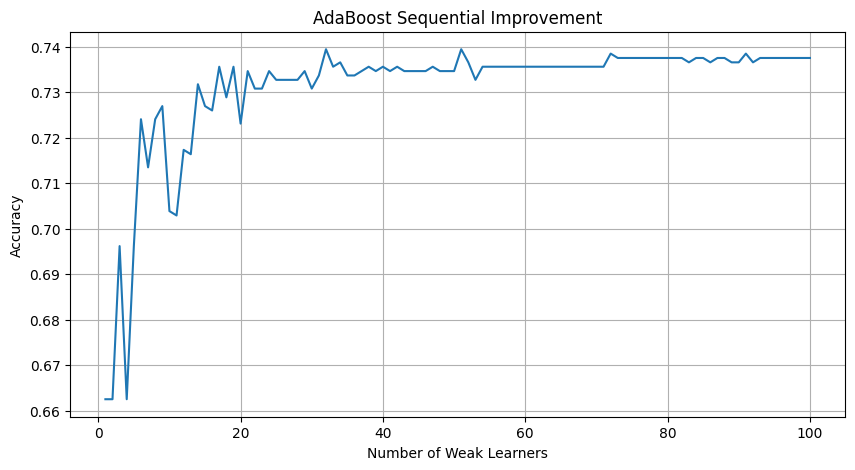

In [143]:
# Q14 Analyze How Weak Learners Improve Sequentially

# Get AdaBoost model from Pipeline
adaboost_model = adaboost_classifier.named_steps["model"]

# Transform test data using the same preprocessor
X_test_c_processed = adaboost_classifier.named_steps[
    "preprocessor"
].transform(X_test_c)

# Store accuracy of each weak learner stage
stage_accuracy = []

for y_pred_stage in adaboost_model.staged_predict(X_test_c_processed):
    accuracy_stage = accuracy_score(
        y_test_c,
        y_pred_stage
    )
    stage_accuracy.append(accuracy_stage)

# Print accuracy at different stages
print("Sequential Improvement of Weak Learners")
print("========================================")

for i, accuracy_stage in enumerate(stage_accuracy, start=1):
    if i == 1 or i % 10 == 0:
        print(
            "Learners:", i,
            "Accuracy:", accuracy_stage
        )

# Plot accuracy improvement
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(stage_accuracy) + 1),
    stage_accuracy
)

plt.xlabel("Number of Weak Learners")
plt.ylabel("Accuracy")
plt.title("AdaBoost Sequential Improvement")

plt.grid(True)
plt.show()

In [144]:
# Q15 Gradient Boosting Classifier

# Create Gradient Boosting Classifier
gradient_boosting_classifier = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

# Train Model
gradient_boosting_classifier.fit(
    X_train_c,
    y_train_c
)

# Prediction
y_pred_gradient_boosting = gradient_boosting_classifier.predict(
    X_test_c
)

# Accuracy
accuracy_gradient_boosting = accuracy_score(
    y_test_c,
    y_pred_gradient_boosting
)

print("Gradient Boosting Classifier Accuracy:",
      accuracy_gradient_boosting)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test_c,
        y_pred_gradient_boosting
    )
)

Gradient Boosting Classifier Accuracy: 0.7298076923076923

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.83      0.79       650
           1       0.66      0.56      0.61       390

    accuracy                           0.73      1040
   macro avg       0.71      0.70      0.70      1040
weighted avg       0.72      0.73      0.72      1040



In [ ]:
# Q16 Gradient Boosting Regressor

# Create Gradient Boosting Regressor
gradient_boosting_regressor = Pipeline([
    ("preprocessor", preprocessor),
    ("model", GradientBoostingRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42
    ))
])

# Train Model
gradient_boosting_regressor.fit(
    X_train_r,
    y_train_r
)

# Prediction
y_pred_gradient_boosting_reg = gradient_boosting_regressor.predict(
    X_test_r
)

# Evaluation
mae_gradient_boosting = mean_absolute_error(
    y_test_r,
    y_pred_gradient_boosting_reg
)

mse_gradient_boosting = mean_squared_error(
    y_test_r,
    y_pred_gradient_boosting_reg
)

rmse_gradient_boosting = np.sqrt(
    mse_gradient_boosting
)

r2_gradient_boosting = r2_score(
    y_test_r,
    y_pred_gradient_boosting_reg
)

print("Gradient Boosting Regressor Results")
print("====================================")
print("MAE:", mae_gradient_boosting)
print("MSE:", mse_gradient_boosting)
print("RMSE:", rmse_gradient_boosting)
print("R2 Score:", r2_gradient_boosting)

Gradient Boosting Regressor Results
MAE: 7.84470652537723
MSE: 96.20800050415943
RMSE: 9.808567709108166
R2 Score: 0.48507693625159254


Gradient Boosting Classifier Analysis
Learning Rate: 0.01 | Estimators: 50 | Accuracy: 0.6692307692307692
Learning Rate: 0.01 | Estimators: 100 | Accuracy: 0.6990384615384615
Learning Rate: 0.01 | Estimators: 150 | Accuracy: 0.7230769230769231
Learning Rate: 0.01 | Estimators: 200 | Accuracy: 0.7298076923076923
Learning Rate: 0.05 | Estimators: 50 | Accuracy: 0.7365384615384616
Learning Rate: 0.05 | Estimators: 100 | Accuracy: 0.7346153846153847
Learning Rate: 0.05 | Estimators: 150 | Accuracy: 0.7365384615384616
Learning Rate: 0.05 | Estimators: 200 | Accuracy: 0.7336538461538461
Learning Rate: 0.1 | Estimators: 50 | Accuracy: 0.7365384615384616
Learning Rate: 0.1 | Estimators: 100 | Accuracy: 0.7298076923076923
Learning Rate: 0.1 | Estimators: 150 | Accuracy: 0.7269230769230769
Learning Rate: 0.1 | Estimators: 200 | Accuracy: 0.7173076923076923
Learning Rate: 0.2 | Estimators: 50 | Accuracy: 0.7269230769230769
Learning Rate: 0.2 | Estimators: 100 | Accuracy: 0.7125
Learning Rate: 0.2

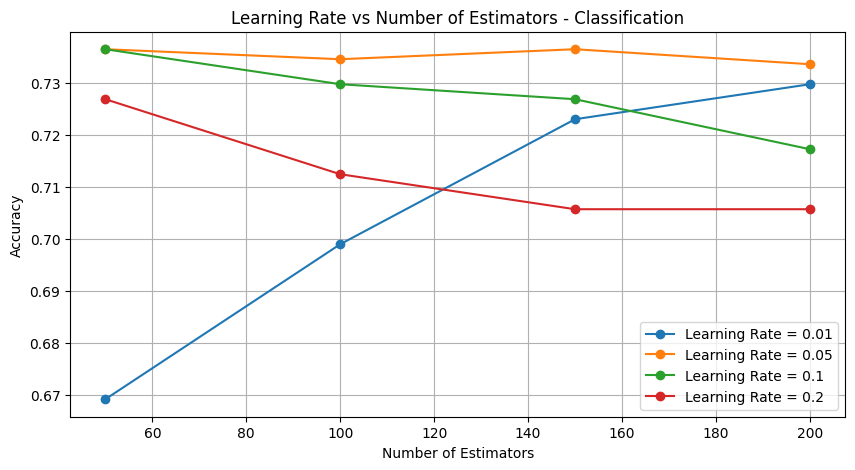

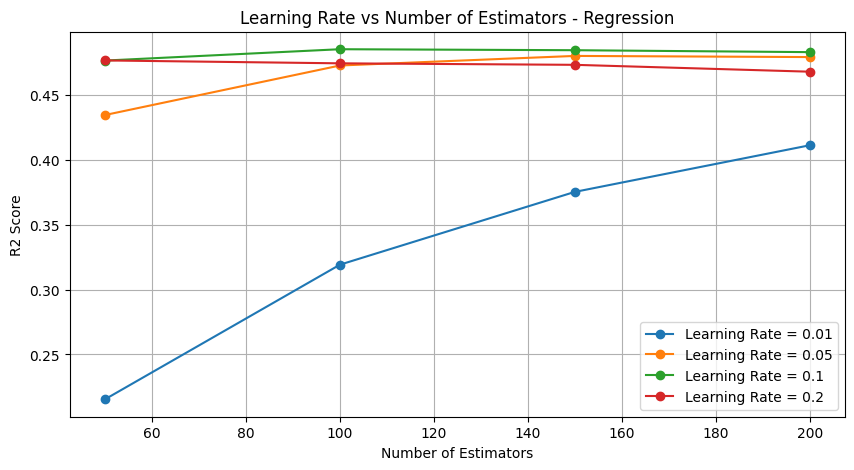

In [146]:
# Q17 Analyze Learning Rate and Number of Estimators

#Classification Analysis

learning_rates = [0.01, 0.05, 0.1, 0.2]
n_estimators_list = [50, 100, 150, 200]

classification_results = []

for lr in learning_rates:
    for n in n_estimators_list:

        model = Pipeline([
            ("preprocessor", preprocessor),
            ("model", GradientBoostingClassifier(
                learning_rate=lr,
                n_estimators=n,
                max_depth=3,
                random_state=42
            ))
        ])

        model.fit(X_train_c, y_train_c)

        y_pred = model.predict(X_test_c)

        accuracy = accuracy_score(
            y_test_c,
            y_pred
        )

        classification_results.append(
            [lr, n, accuracy]
        )


print("Gradient Boosting Classifier Analysis")
print("=====================================")

for result in classification_results:
    print(
        "Learning Rate:", result[0],
        "| Estimators:", result[1],
        "| Accuracy:", result[2]
    )


# Regression Analysis

regression_results = []

for lr in learning_rates:
    for n in n_estimators_list:

        model = Pipeline([
            ("preprocessor", preprocessor),
            ("model", GradientBoostingRegressor(
                learning_rate=lr,
                n_estimators=n,
                max_depth=3,
                random_state=42
            ))
        ])

        model.fit(X_train_r, y_train_r)
        y_pred = model.predict(X_test_r)
        r2 = r2_score(
            y_test_r,
            y_pred
        )

        regression_results.append(
            [lr, n, r2]
        )


print("\nGradient Boosting Regressor Analysis")
print("====================================")

for result in regression_results:
    print(
        "Learning Rate:", result[0],
        "| Estimators:", result[1],
        "| R2 Score:", result[2]
    )

# Classification Graph

plt.figure(figsize=(10, 5))

for lr in learning_rates:

    values = [
        result[2]
        for result in classification_results
        if result[0] == lr
    ]

    plt.plot(
        n_estimators_list,
        values,
        marker="o",
        label=f"Learning Rate = {lr}"
    )

plt.xlabel("Number of Estimators")
plt.ylabel("Accuracy")
plt.title("Learning Rate vs Number of Estimators - Classification")
plt.legend()
plt.grid(True)
plt.show()



#Regression Graph

plt.figure(figsize=(10, 5))

for lr in learning_rates:

    values = [
        result[2]
        for result in regression_results
        if result[0] == lr
    ]

    plt.plot(
        n_estimators_list,
        values,
        marker="o",
        label=f"Learning Rate = {lr}"
    )

plt.xlabel("Number of Estimators")
plt.ylabel("R2 Score")
plt.title("Learning Rate vs Number of Estimators - Regression")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Q18 LightGBM Classifier

# Create LightGBM Classifier
lightgbm_classifier = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        verbosity=-1
    ))
])

# Train Model
lightgbm_classifier.fit(
    X_train_c,
    y_train_c
)

# Prediction
y_pred_lightgbm = lightgbm_classifier.predict(
    X_test_c
)

# Accuracy
accuracy_lightgbm = accuracy_score(
    y_test_c,
    y_pred_lightgbm
)

print("LightGBM Classifier Accuracy:",
      accuracy_lightgbm)

# Classification Report
print("\nClassification Report:")
print(
    classification_report(
        y_test_c,
        y_pred_lightgbm
    )
)

LightGBM Classifier Accuracy: 0.7355769230769231

Classification Report:
              precision    recall  f1-score   support

           0       0.77      0.83      0.80       650
           1       0.67      0.58      0.62       390

    accuracy                           0.74      1040
   macro avg       0.72      0.70      0.71      1040
weighted avg       0.73      0.74      0.73      1040



In [148]:
# Q19 LightGBM Regressor

# Create LightGBM Regressor
lightgbm_regressor = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LGBMRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        verbosity=-1
    ))
])

# Train Model
lightgbm_regressor.fit(
    X_train_r,
    y_train_r
)

# Prediction
y_pred_lightgbm_reg = lightgbm_regressor.predict(
    X_test_r
)

# Evaluation
mae_lightgbm = mean_absolute_error(
    y_test_r,
    y_pred_lightgbm_reg
)

mse_lightgbm = mean_squared_error(
    y_test_r,
    y_pred_lightgbm_reg
)

rmse_lightgbm = np.sqrt(
    mse_lightgbm
)

r2_lightgbm = r2_score(
    y_test_r,
    y_pred_lightgbm_reg
)

print("LightGBM Regressor Results")
print("==========================")
print("MAE  :", mae_lightgbm)
print("MSE  :", mse_lightgbm)
print("RMSE :", rmse_lightgbm)
print("R2 Score:", r2_lightgbm)

LightGBM Regressor Results
MAE  : 7.904587699045391
MSE  : 96.46255376372876
RMSE : 9.821535204016161
R2 Score: 0.4837145199908065


In [149]:
# Q20 Performance and Training Efficiency Comparison

# LightGBM Classifier
start_time = time.time()

lightgbm_classifier.fit(
    X_train_c,
    y_train_c
)

classification_training_time = time.time() - start_time

y_pred_lightgbm = lightgbm_classifier.predict(
    X_test_c
)

lightgbm_accuracy = accuracy_score(
    y_test_c,
    y_pred_lightgbm
)

#LightGBM Regressor

start_time = time.time()

lightgbm_regressor.fit(
    X_train_r,
    y_train_r
)

regression_training_time = time.time() - start_time

y_pred_lightgbm_reg = lightgbm_regressor.predict(
    X_test_r
)

lightgbm_r2 = r2_score(
    y_test_r,
    y_pred_lightgbm_reg
)


print("LightGBM Performance & Training Efficiency")
print("==========================================")

print("\nClassification:")
print("Accuracy :", lightgbm_accuracy)
print("Training Time :", classification_training_time, "seconds")

print("\nRegression:")
print("R2 Score :", lightgbm_r2)
print("Training Time :", regression_training_time, "seconds")

LightGBM Performance & Training Efficiency

Classification:
Accuracy : 0.7355769230769231
Training Time : 0.07988405227661133 seconds

Regression:
R2 Score : 0.4837145199908065
Training Time : 0.06844449043273926 seconds


In [150]:
# Q21 XGBoost Classifier

xgboost_classifier = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        eval_metric="logloss"
    ))
])

xgboost_classifier.fit(
    X_train_c,
    y_train_c
)

y_pred_xgboost = xgboost_classifier.predict(
    X_test_c
)

accuracy_xgboost = accuracy_score(
    y_test_c,
    y_pred_xgboost
)

print("XGBoost Classifier Accuracy:",
      accuracy_xgboost)

print("\nClassification Report:")
print(
    classification_report(
        y_test_c,
        y_pred_xgboost
    )
)

XGBoost Classifier Accuracy: 0.7375

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.84      0.80       650
           1       0.68      0.57      0.62       390

    accuracy                           0.74      1040
   macro avg       0.72      0.70      0.71      1040
weighted avg       0.73      0.74      0.73      1040



In [151]:
# Q22 XGBoost Regressor

xgboost_regressor = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        objective="reg:squarederror"
    ))
])

xgboost_regressor.fit(
    X_train_r,
    y_train_r
)

y_pred_xgboost_reg = xgboost_regressor.predict(
    X_test_r
)

mae_xgboost = mean_absolute_error(
    y_test_r,
    y_pred_xgboost_reg
)

mse_xgboost = mean_squared_error(
    y_test_r,
    y_pred_xgboost_reg
)

rmse_xgboost = np.sqrt(
    mse_xgboost
)

r2_xgboost = r2_score(
    y_test_r,
    y_pred_xgboost_reg
)

print("XGBoost Regressor")
print("=========================")
print("MAE  :", mae_xgboost)
print("MSE  :", mse_xgboost)
print("RMSE :", rmse_xgboost)
print("R2 Score:", r2_xgboost)

XGBoost Regressor
MAE  : 7.878666351024919
MSE  : 96.67160594803778
RMSE : 9.832171985275572
R2 Score: 0.4825956339245375


In [152]:
# Q23 Performance and Robustness Comparison

# Classification Comparison

accuracy_bagging = accuracy_score(
    y_test_c,
    y_pred_bagging
)

accuracy_adaboost = accuracy_score(
    y_test_c,
    y_pred_adaboost
)

accuracy_gradient = accuracy_score(
    y_test_c,
    y_pred_gradient_boosting
)

accuracy_lightgbm = accuracy_score(
    y_test_c,
    y_pred_lightgbm
)

accuracy_xgboost = accuracy_score(
    y_test_c,
    y_pred_xgboost
)


# Regression Comparison

r2_bagging = r2_score(
    y_test_r,
    y_pred_bagging_reg
)

r2_adaboost = r2_score(
    y_test_r,
    y_pred_adaboost_reg
)

r2_gradient = r2_score(
    y_test_r,
    y_pred_gradient_boosting_reg
)

r2_lightgbm = r2_score(
    y_test_r,
    y_pred_lightgbm_reg
)

r2_xgboost = r2_score(
    y_test_r,
    y_pred_xgboost_reg
)


# Classification 

print("CLASSIFICATION PERFORMANCE")
print("==========================")

classification_comparison = {
    "Bagging": accuracy_bagging,
    "AdaBoost": accuracy_adaboost,
    "Gradient Boosting": accuracy_gradient,
    "LightGBM": accuracy_lightgbm,
    "XGBoost": accuracy_xgboost
}

for model, score in classification_comparison.items():
    print(f"{model}: {score:.4f}")


#Regression Results
print("\nREGRESSION PERFORMANCE")
print("======================")

regression_comparison = {
    "Bagging": r2_bagging,
    "AdaBoost": r2_adaboost,
    "Gradient Boosting": r2_gradient,
    "LightGBM": r2_lightgbm,
    "XGBoost": r2_xgboost
}

for model, score in regression_comparison.items():
    print(f"{model}: {score:.4f}")


# Best Models

best_classification = max(
    classification_comparison,
    key=classification_comparison.get
)

best_regression = max(
    regression_comparison,
    key=regression_comparison.get
)

print("\nBEST MODELS")
print("===========")
print("Best Classification Model:",
      best_classification)

print("Best Regression Model:",
      best_regression)

CLASSIFICATION PERFORMANCE
Bagging: 0.7173
AdaBoost: 0.7365
Gradient Boosting: 0.7298
LightGBM: 0.7356
XGBoost: 0.7375

REGRESSION PERFORMANCE
Bagging: 0.4642
AdaBoost: 0.2946
Gradient Boosting: 0.4851
LightGBM: 0.4837
XGBoost: 0.4826

BEST MODELS
Best Classification Model: XGBoost
Best Regression Model: Gradient Boosting


In [153]:
# Q24 Voting Classifier

# Create Voting Classifier
voting_classifier = Pipeline([
    ("preprocessor", preprocessor),
    ("model", VotingClassifier(
        estimators=[
            ("logistic", LogisticRegression(
                max_iter=1000,
                random_state=42
            )),
            ("decision_tree", DecisionTreeClassifier(
                max_depth=5,
                random_state=42
            )),
            ("xgboost", XGBClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42,
                eval_metric="logloss"
            ))
        ],
        voting="soft"
    ))
])

# Train Model
voting_classifier.fit(
    X_train_c,
    y_train_c
)

# Prediction
y_pred_voting = voting_classifier.predict(
    X_test_c
)

# Accuracy
accuracy_voting = accuracy_score(
    y_test_c,
    y_pred_voting
)


print("Voting Classifier Accuracy:",
      accuracy_voting)

print("\nClassification Report:")
print(
    classification_report(
        y_test_c,
        y_pred_voting
    )
)

Voting Classifier Accuracy: 0.7221153846153846

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.83      0.79       650
           1       0.66      0.54      0.59       390

    accuracy                           0.72      1040
   macro avg       0.70      0.69      0.69      1040
weighted avg       0.72      0.72      0.72      1040



In [ ]:
# Q25 Hard Voting vs Soft Voting

#Hard Voting

hard_voting_classifier = Pipeline([
    ("preprocessor", preprocessor),
    ("model", VotingClassifier(
        estimators=[
            ("logistic", LogisticRegression(
                max_iter=1000,
                random_state=42
            )),
            ("decision_tree", DecisionTreeClassifier(
                max_depth=5,
                random_state=42
            )),
            ("xgboost", XGBClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42,
                eval_metric="logloss"
            ))
        ],
        voting="hard"
    ))
])

hard_voting_classifier.fit(
    X_train_c,
    y_train_c
)

y_pred_hard = hard_voting_classifier.predict(
    X_test_c
)

hard_voting_accuracy = accuracy_score(
    y_test_c,
    y_pred_hard
)


# Soft Voting

soft_voting_classifier = Pipeline([
    ("preprocessor", preprocessor),
    ("model", VotingClassifier(
        estimators=[
            ("logistic", LogisticRegression(
                max_iter=1000,
                random_state=42
            )),
            ("decision_tree", DecisionTreeClassifier(
                max_depth=5,
                random_state=42
            )),
            ("xgboost", XGBClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42,
                eval_metric="logloss"
            ))
        ],
        voting="soft"
    ))
])

soft_voting_classifier.fit(
    X_train_c,
    y_train_c
)

y_pred_soft = soft_voting_classifier.predict(
    X_test_c
)

soft_voting_accuracy = accuracy_score(
    y_test_c,
    y_pred_soft
)


# Comparison
print("Hard Voting vs Soft Voting")
print("==========================")

print("Hard Voting Accuracy:",
      hard_voting_accuracy)

print("Soft Voting Accuracy:",
      soft_voting_accuracy)


# Best Method
if soft_voting_accuracy > hard_voting_accuracy:
    print("\nBetter Method: Soft Voting")
elif hard_voting_accuracy > soft_voting_accuracy:
    print("\nBetter Method: Hard Voting")
else:
    print("\nBoth methods have the same accuracy.")

Hard Voting vs Soft Voting
Hard Voting Accuracy: 0.7326923076923076
Soft Voting Accuracy: 0.7221153846153846

Better Method: Hard Voting


In [155]:
# Q26 Stacking Classifier

# Stacking Classifier
stacking_classifier = Pipeline([
    ("preprocessor", preprocessor),
    ("model", StackingClassifier(
        estimators=[
            ("decision_tree", DecisionTreeClassifier(
                max_depth=5,
                random_state=42
            )),
            ("xgboost", XGBClassifier(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42,
                eval_metric="logloss"
            ))
        ],
        final_estimator=LogisticRegression(
            max_iter=1000,
            random_state=42
        ),
        cv=5,
        n_jobs=-1
    ))
])

# Train Model
stacking_classifier.fit(
    X_train_c,
    y_train_c
)


# Prediction
y_pred_stacking = stacking_classifier.predict(
    X_test_c
)

# Evaluation
accuracy_stacking = accuracy_score(
    y_test_c,
    y_pred_stacking
)

print("Stacking Classifier Accuracy:",
      accuracy_stacking)

print("\nClassification Report:")

print(
    classification_report(
        y_test_c,
        y_pred_stacking
    )
)

Stacking Classifier Accuracy: 0.7413461538461539

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       650
           1       0.69      0.56      0.62       390

    accuracy                           0.74      1040
   macro avg       0.73      0.71      0.71      1040
weighted avg       0.74      0.74      0.73      1040



In [156]:
# Q27 Stacking Regressor

# Stacking Regressor
stacking_regressor = Pipeline([
    ("preprocessor", preprocessor),
    ("model", StackingRegressor(
        estimators=[
            ("decision_tree", DecisionTreeRegressor(
                max_depth=5,
                random_state=42
            )),
            ("xgboost", XGBRegressor(
                n_estimators=100,
                learning_rate=0.1,
                max_depth=3,
                random_state=42,
                objective="reg:squarederror"
            ))
        ],
        final_estimator=LinearRegression(),
        cv=5,
        n_jobs=-1
    ))
])


# Train Model
stacking_regressor.fit(
    X_train_r,
    y_train_r
)


# Prediction
y_pred_stacking_reg = stacking_regressor.predict(
    X_test_r
)


# Evaluation
mae_stacking = mean_absolute_error(
    y_test_r,
    y_pred_stacking_reg
)

mse_stacking = mean_squared_error(
    y_test_r,
    y_pred_stacking_reg
)

rmse_stacking = np.sqrt(
    mse_stacking
)

r2_stacking = r2_score(
    y_test_r,
    y_pred_stacking_reg
)


print("Stacking Regressor Results")
print("==========================")
print("MAE  :", mae_stacking)
print("MSE  :", mse_stacking)
print("RMSE :", rmse_stacking)
print("R2 Score:", r2_stacking)

Stacking Regressor Results
MAE  : 7.869019051327921
MSE  : 96.59138014059364
RMSE : 9.828091378319273
R2 Score: 0.48302501732658665


In [157]:
# Q28 Evaluate Classification Models

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,roc_auc_score)
classification_models = {
    "Bagging": (bagging_classifier, y_pred_bagging),
    "AdaBoost": (adaboost_classifier, y_pred_adaboost),
    "Gradient Boosting": (gradient_boosting_classifier, y_pred_gradient_boosting),
    "LightGBM": (lightgbm_classifier, y_pred_lightgbm),
    "XGBoost": (xgboost_classifier, y_pred_xgboost),
    "Voting": (voting_classifier, y_pred_voting),
    "Stacking": (stacking_classifier, y_pred_stacking)
}

classification_results = []

for name, (model, predictions) in classification_models.items():

    accuracy = accuracy_score(
        y_test_c,
        predictions
    )

    precision = precision_score(
        y_test_c,
        predictions,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_test_c,
        predictions,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_test_c,
        predictions,
        average="weighted",
        zero_division=0
    )

    # ROC-AUC
    try:
        probabilities = model.predict_proba(X_test_c)

        if probabilities.shape[1] == 2:
            roc_auc = roc_auc_score(
                y_test_c,
                probabilities[:, 1]
            )
        else:
            roc_auc = roc_auc_score(
                y_test_c,
                probabilities,
                multi_class="ovr",
                average="weighted"
            )

    except:
        roc_auc = np.nan

    classification_results.append([
        name,
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ])


classification_results_df = pd.DataFrame(
    classification_results,
    columns=[
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
)

print("Classification Model Evaluation")
print("================================")

print(
    classification_results_df.round(4)
)

Classification Model Evaluation
               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0            Bagging    0.7173     0.7117  0.7173    0.7126   0.7759
1           AdaBoost    0.7365     0.7312  0.7365    0.7286   0.7853
2  Gradient Boosting    0.7298     0.7244  0.7298    0.7246   0.7813
3           LightGBM    0.7356     0.7306  0.7356    0.7309   0.7870
4            XGBoost    0.7375     0.7323  0.7375    0.7318   0.7792
5             Voting    0.7221     0.7158  0.7221    0.7154   0.7786
6           Stacking    0.7413     0.7362  0.7413    0.7349   0.7791


In [158]:
# Q29 Evaluate Regression Models

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

regression_models = {
    "Bagging": y_pred_bagging_reg,
    "AdaBoost": y_pred_adaboost_reg,
    "Gradient Boosting": y_pred_gradient_boosting_reg,
    "LightGBM": y_pred_lightgbm_reg,
    "XGBoost": y_pred_xgboost_reg,
    "Stacking": y_pred_stacking_reg
}

regression_results = []

for name, predictions in regression_models.items():

    mae = mean_absolute_error(
        y_test_r,
        predictions
    )

    mse = mean_squared_error(
        y_test_r,
        predictions
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test_r,
        predictions
    )

    regression_results.append([
        name,
        mae,
        rmse,
        r2
    ])


regression_results_df = pd.DataFrame(
    regression_results,
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

print("Regression Model Evaluation")
print("============================")

print(
    regression_results_df.round(4)
)

Regression Model Evaluation
               Model     MAE     RMSE  R2 Score
0            Bagging  8.0050  10.0052    0.4642
1           AdaBoost  9.3846  11.4805    0.2946
2  Gradient Boosting  7.8447   9.8086    0.4851
3           LightGBM  7.9046   9.8215    0.4837
4            XGBoost  7.8787   9.8322    0.4826
5           Stacking  7.8690   9.8281    0.4830


In [159]:
# Q30 Compare All Ensemble Techniques
# and Identify Best Performing Model

print("CLASSIFICATION MODEL COMPARISON")
print("================================")

print(
    classification_results_df.round(4)
)

# Best Classification Model
best_classification_model = (
    classification_results_df
    .loc[
        classification_results_df["F1-Score"].idxmax(),
        "Model"
    ]
)

best_classification_accuracy = (
    classification_results_df["Accuracy"].max()
)

print("\nBest Classification Model:",
      best_classification_model)

print("Best Classification Accuracy:",
      best_classification_accuracy)


print("\n\nREGRESSION MODEL COMPARISON")
print("============================")

print(
    regression_results_df.round(4)
)

# Best Regression Model
best_regression_model = (
    regression_results_df
    .loc[
        regression_results_df["R2 Score"].idxmax(),
        "Model"
    ]
)

best_regression_r2 = (
    regression_results_df["R2 Score"].max()
)

print("\nBest Regression Model:",
      best_regression_model)

print("Best Regression R2 Score:",
      best_regression_r2)


# --------------------------------
# Final Recommendation
# --------------------------------

print("\n\nFINAL MODEL RECOMMENDATION")
print("==========================")

print("Classification:",best_classification_model)

print("Regression:",best_regression_model)

CLASSIFICATION MODEL COMPARISON
               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0            Bagging    0.7173     0.7117  0.7173    0.7126   0.7759
1           AdaBoost    0.7365     0.7312  0.7365    0.7286   0.7853
2  Gradient Boosting    0.7298     0.7244  0.7298    0.7246   0.7813
3           LightGBM    0.7356     0.7306  0.7356    0.7309   0.7870
4            XGBoost    0.7375     0.7323  0.7375    0.7318   0.7792
5             Voting    0.7221     0.7158  0.7221    0.7154   0.7786
6           Stacking    0.7413     0.7362  0.7413    0.7349   0.7791

Best Classification Model: Stacking
Best Classification Accuracy: 0.7413461538461539


REGRESSION MODEL COMPARISON
               Model     MAE     RMSE  R2 Score
0            Bagging  8.0050  10.0052    0.4642
1           AdaBoost  9.3846  11.4805    0.2946
2  Gradient Boosting  7.8447   9.8086    0.4851
3           LightGBM  7.9046   9.8215    0.4837
4            XGBoost  7.8787   9.8322    0.4826
5           

1. IMPACT OF BAGGING VS BOOSTING

Bagging:
- Multiple models are trained independently.
- It mainly reduces variance.
- It improves model stability.
- Example: Bagging Classifier and Bagging Regressor.

Boosting:
- Models are trained sequentially.
- Each new model tries to correct previous errors.
- It can improve predictive performance.
- Examples: AdaBoost, Gradient Boosting, LightGBM and XGBoost.

2. COMPARISON OF TREE-BASED BOOSTING ALGORITHMS

Classification Performance:
               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
1           AdaBoost    0.7365     0.7312  0.7365    0.7286   0.7853
2  Gradient Boosting    0.7298     0.7244  0.7298    0.7246   0.7813
3           LightGBM    0.7356     0.7306  0.7356    0.7309   0.7870
4            XGBoost    0.7375     0.7323  0.7375    0.7318   0.7792

3. ADVANTAGES OF VOTING AND STACKING

Voting:
- Combines predictions from multiple models.
- Hard Voting uses majority voting.
- Soft Voting uses prediction probabilities.
-

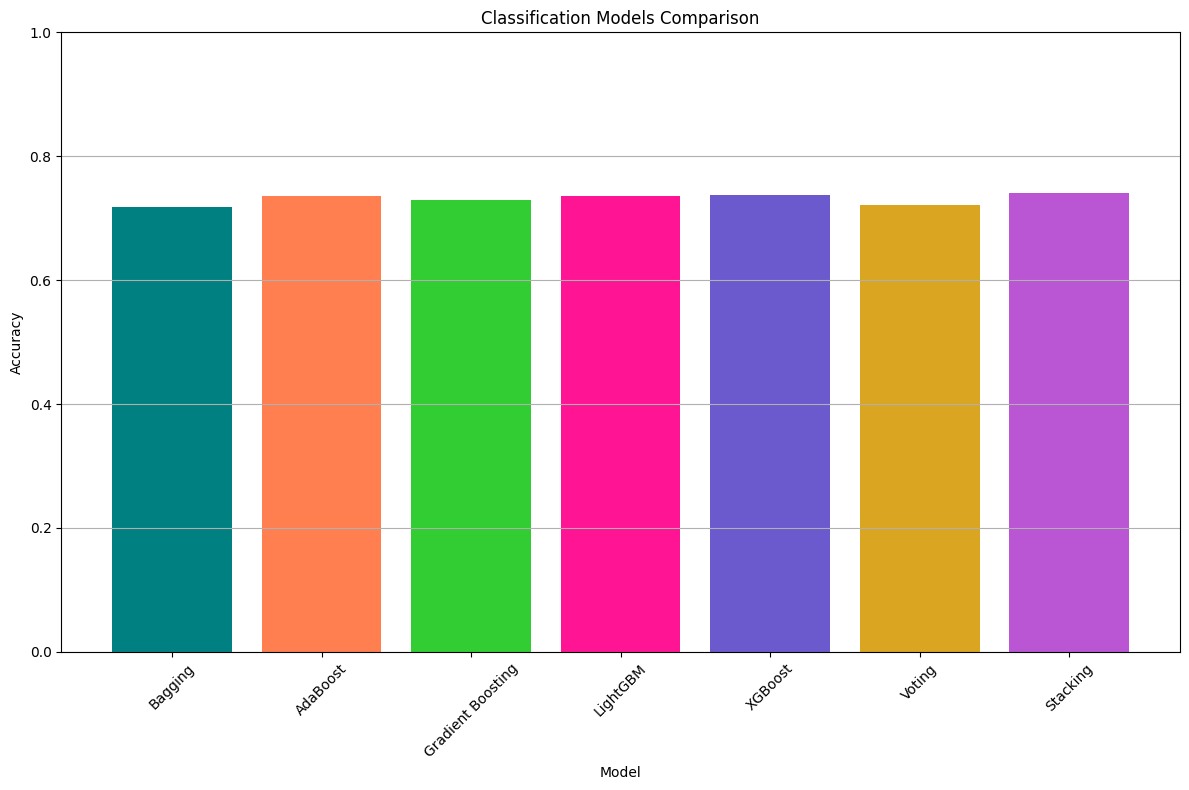

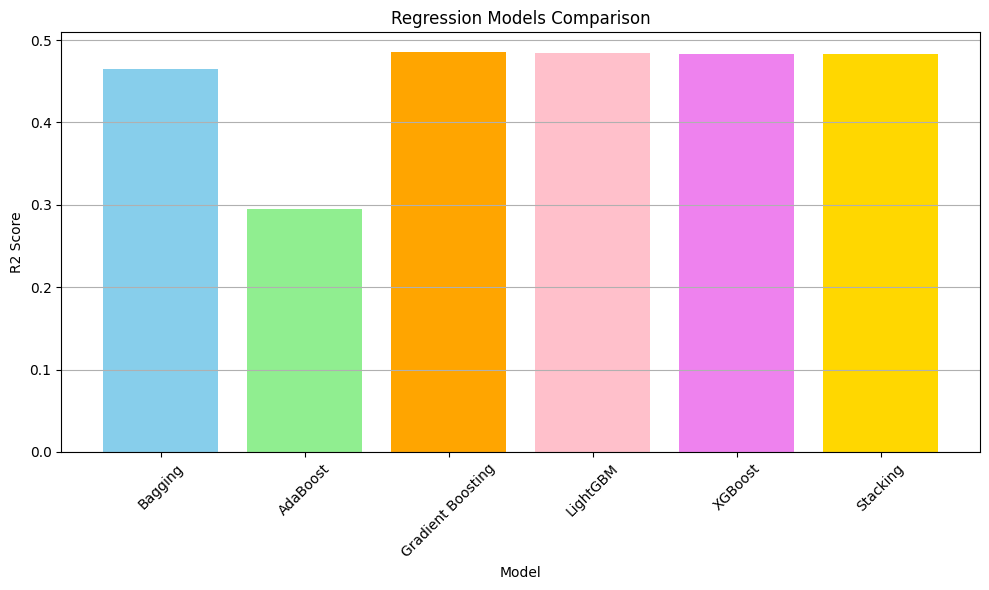


FINAL CONCLUSION

For the classification task, Stacking
performed best based on the highest F1-Score.

For the regression task, Gradient Boosting
performed best based on the highest R2 Score.

The ensemble techniques showed that combining multiple
learners can improve prediction quality and robustness.

For deployment, the selected models should also be checked
for training time, prediction speed, robustness and
business requirements before final implementation.

FINAL REPORT COMPLETED SUCCESSFULLY


In [ ]:
# Q31 Final Analysis & Reporting

#Impact of Bagging vs Boosting

print("=" * 70)
print("1. IMPACT OF BAGGING VS BOOSTING")
print("=" * 70)

print("""
Bagging:
- Multiple models are trained independently.
- It mainly reduces variance.
- It improves model stability.
- Example: Bagging Classifier and Bagging Regressor.

Boosting:
- Models are trained sequentially.
- Each new model tries to correct previous errors.
- It can improve predictive performance.
- Examples: AdaBoost, Gradient Boosting, LightGBM and XGBoost.
""")

#Comparison Of Tree Based Boosting Algorithms


print("=" * 70)
print("2. COMPARISON OF TREE-BASED BOOSTING ALGORITHMS")
print("=" * 70)

boosting_models = [
    "AdaBoost",
    "Gradient Boosting",
    "LightGBM",
    "XGBoost"
]

boosting_comparison = classification_results_df[
    classification_results_df["Model"].isin(boosting_models)
].copy()

print("\nClassification Performance:")
print(boosting_comparison.round(4))


# Advantages Of Voting And Stacking 
print("\n" + "=" * 70)
print("3. ADVANTAGES OF VOTING AND STACKING")
print("=" * 70)

print("""
Voting:
- Combines predictions from multiple models.
- Hard Voting uses majority voting.
- Soft Voting uses prediction probabilities.
- Simple and easy to implement.

Stacking:
- Combines different base models.
- A final model learns from the base-model predictions.
- Can capture different strengths of individual models.
- Often provides strong predictive performance.
""")


# Classification Model Performance
print("=" * 70)
print("CLASSIFICATION MODEL PERFORMANCE")
print("=" * 70)

print(
    classification_results_df.round(4)
)


# Regression Model Performance

print("\n" + "=" * 70)
print("REGRESSION MODEL PERFORMANCE")
print("=" * 70)

print(
    regression_results_df.round(4)
)

# Find Best Classification Model

best_classification_model = (
    classification_results_df
    .loc[
        classification_results_df["F1-Score"].idxmax(),
        "Model"
    ]
)

best_classification_f1 = (
    classification_results_df["F1-Score"].max()
)

best_classification_accuracy = (
    classification_results_df[
        classification_results_df["Model"]
        == best_classification_model
    ]["Accuracy"].iloc[0]
)

# Find Best Redression Model 

best_regression_model = (
    regression_results_df
    .loc[
        regression_results_df["R2 Score"].idxmax(),
        "Model"
    ]
)

best_regression_r2 = (
    regression_results_df["R2 Score"].max()
)

#  Final Model Recommendation

print("\n" + "=" * 70)
print("4. FINAL MODEL RECOMMENDATION FOR DEPLOYMENT")
print("=" * 70)

print(
    "\nRecommended Classification Model:",
    best_classification_model
)

print(
    "Classification Accuracy:",
    round(best_classification_accuracy, 4)
)

print(
    "Classification F1-Score:",
    round(best_classification_f1, 4)
)

print(
    "\nRecommended Regression Model:",
    best_regression_model
)

print(
    "Regression R2 Score:",
    round(best_regression_r2, 4)
)

# Classification plot
plt.figure(figsize=(12, 8))

colors = [
    "teal",
    "coral",
    "limegreen",
    "deeppink",
    "slateblue",
    "goldenrod",
    "mediumorchid",
    "turquoise"
]

plt.bar(
    classification_results_df["Model"],
    classification_results_df["Accuracy"],
    color=colors[:len(classification_results_df)]
)

plt.xlabel("Model")

plt.ylabel("Accuracy")

plt.title("Classification Models Comparison")

plt.xticks(rotation=45)

plt.ylim(0, 1)

plt.grid(axis="y")

plt.tight_layout()

plt.show()

# Regression Plot
plt.figure(figsize=(10, 6))

colors = [
    "skyblue",
    "lightgreen",
    "orange",
    "pink",
    "violet",
    "gold",
    "tomato",
    "cyan"
]

plt.bar(
    regression_results_df["Model"],
    regression_results_df["R2 Score"],
    color=colors[:len(regression_results_df)]
)

plt.xlabel("Model")

plt.ylabel("R2 Score")

plt.title("Regression Models Comparison")

plt.xticks(rotation=45)

plt.grid(axis="y")

plt.tight_layout()

plt.show()
#Final Conclusion

print("\n" + "=" * 70)
print("FINAL CONCLUSION")
print("=" * 70)

print(f"""
For the classification task, {best_classification_model}
performed best based on the highest F1-Score.

For the regression task, {best_regression_model}
performed best based on the highest R2 Score.

The ensemble techniques showed that combining multiple
learners can improve prediction quality and robustness.

For deployment, the selected models should also be checked
for training time, prediction speed, robustness and
business requirements before final implementation.
""")

print("=" * 70)
print("FINAL REPORT COMPLETED SUCCESSFULLY")
print("=" * 70)

CLASSIFICATION EVALUATION TABLE


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Bagging,0.7173,0.7117,0.7173,0.7126,0.7759
1,AdaBoost,0.7365,0.7312,0.7365,0.7286,0.7853
2,Gradient Boosting,0.7298,0.7244,0.7298,0.7246,0.7813
3,LightGBM,0.7356,0.7306,0.7356,0.7309,0.7870
4,XGBoost,0.7375,0.7323,0.7375,0.7318,0.7792
5,Voting,0.7221,0.7158,0.7221,0.7154,0.7786
6,Stacking,0.7413,0.7362,0.7413,0.7349,0.7791



REGRESSION EVALUATION TABLE


,Model,MAE,RMSE,R2 Score
0,Bagging,8.0050,10.0052,0.4642
1,AdaBoost,9.3846,11.4805,0.2946
2,Gradient Boosting,7.8447,9.8086,0.4851
3,LightGBM,7.9046,9.8215,0.4837
4,XGBoost,7.8787,9.8322,0.4826
5,Stacking,7.8690,9.8281,0.4830


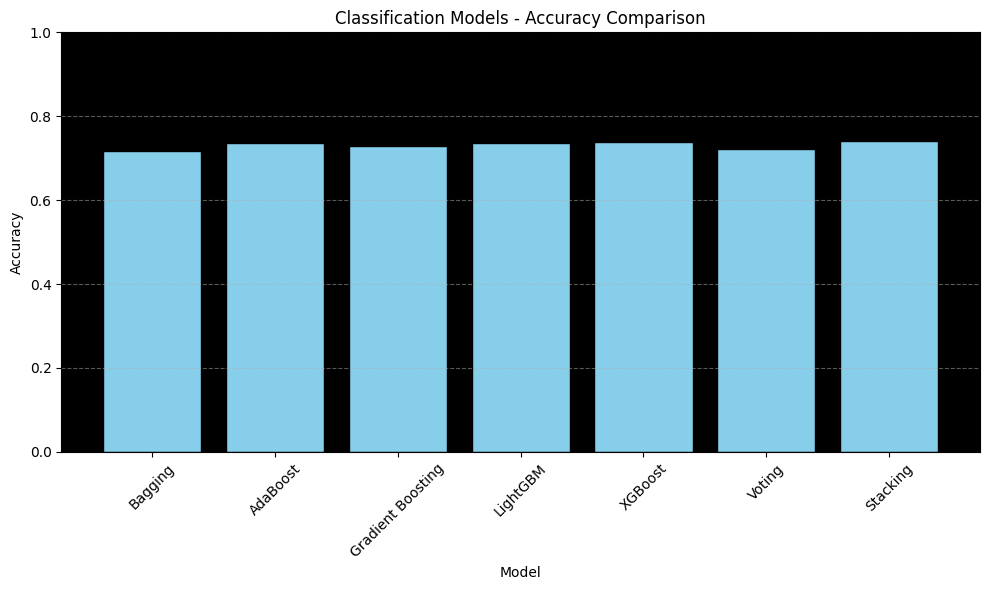

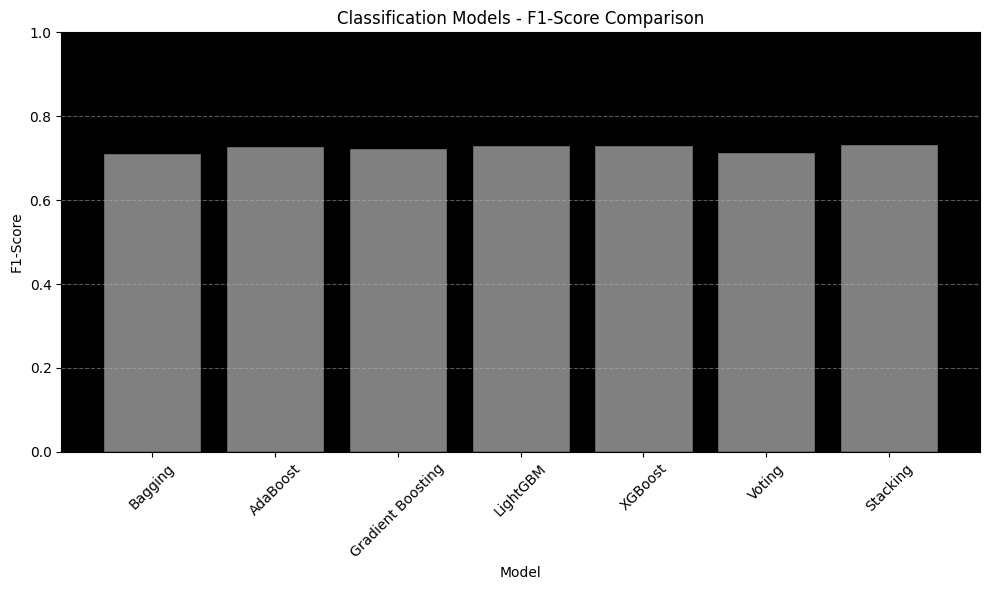

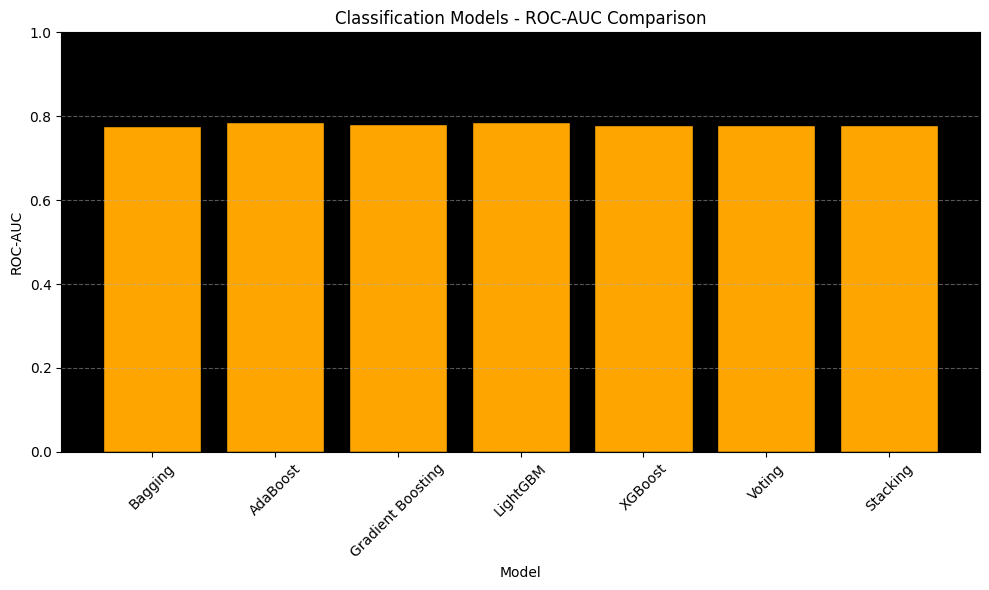

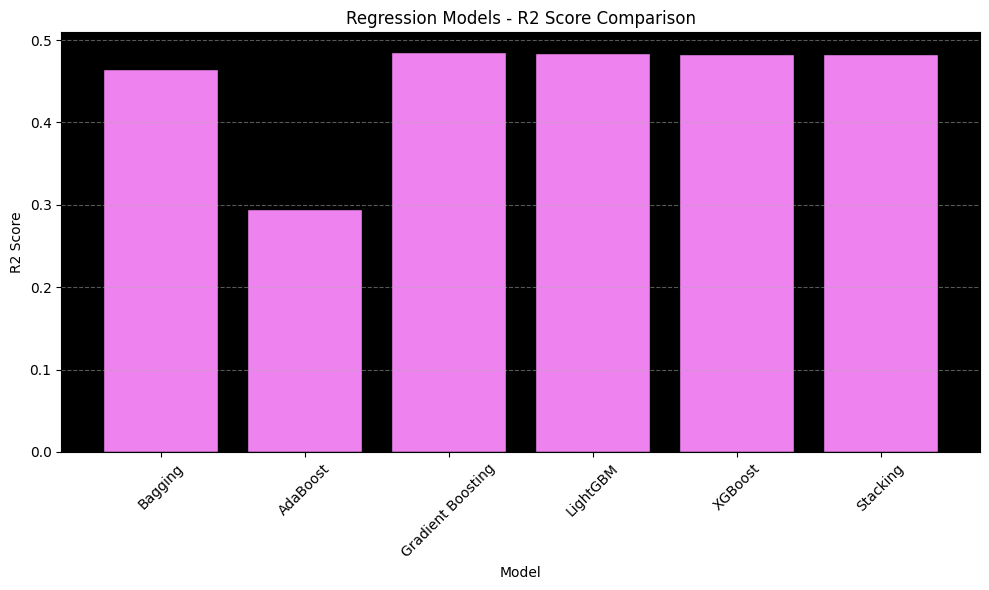

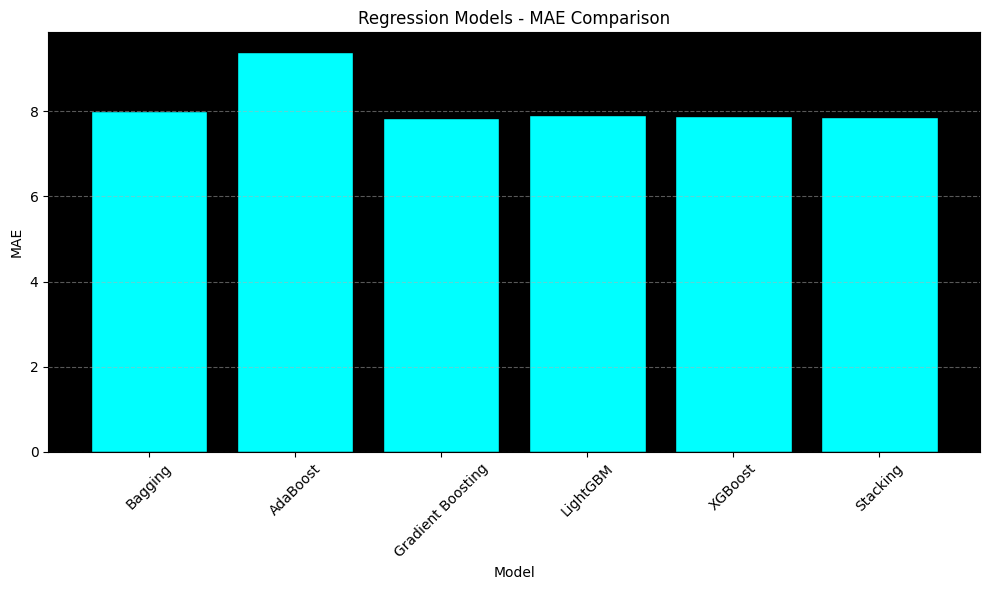

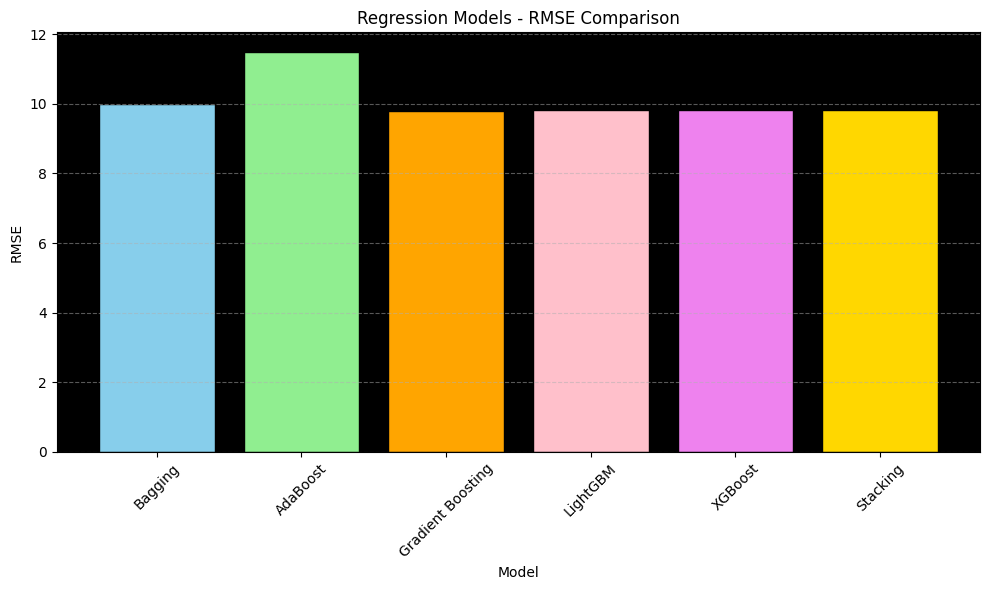

In [197]:
# Q32 Evaluation Tables and Plots

# Classification Evaluation Table
print("=" * 70)
print("CLASSIFICATION EVALUATION TABLE")
print("=" * 70)

classification_table = classification_results_df.round(4)

display(classification_table)

# Regression Evaluation Table
print("\n" + "=" * 70)
print("REGRESSION EVALUATION TABLE")
print("=" * 70)

regression_table = regression_results_df.round(4)

display(regression_table)


# Classification Accuracy Plot
plt.figure(figsize=(10, 6))

plt.bar(
    classification_results_df["Model"],
    classification_results_df["Accuracy"],
    color="skyblue",
    edgecolor="black"
)

plt.title("Classification Models - Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")

plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.grid(axis="y", linestyle="--", alpha=0.5)

# Chart background color
plt.gca().set_facecolor("black")

# Figure background color
plt.gcf().set_facecolor("white")

plt.tight_layout()
plt.show()

# Classification F1 Score Plot
plt.figure(figsize=(10, 6))

colors = [
    "grey","grey","grey","grey","grey","grey"
]

plt.bar(
    classification_results_df["Model"],
    classification_results_df["F1-Score"],
    color=colors[:len(classification_results_df)],
    edgecolor="black"
)

plt.title("Classification Models - F1-Score Comparison")
plt.xlabel("Model")
plt.ylabel("F1-Score")

plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.gca().set_facecolor("black")
plt.gcf().set_facecolor("white")

plt.tight_layout()
plt.show()


# ROC-AUC Plot
plt.figure(figsize=(10, 6))

colors = [
    "orange","orange","orange","orange","orange","orange","orange"
          ]

plt.bar(
    classification_results_df["Model"],
    classification_results_df["ROC-AUC"],
    color=colors[:len(classification_results_df)],
    edgecolor="black"
)

plt.title("Classification Models - ROC-AUC Comparison")
plt.xlabel("Model")
plt.ylabel("ROC-AUC")

plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.grid(axis="y", linestyle="--", alpha=0.5)

# Chart background color
plt.gca().set_facecolor("black")

# Outer figure background color
plt.gcf().set_facecolor("white")

plt.tight_layout()
plt.show()

# Regression R2 Score Plot  
plt.figure(figsize=(10, 6))

colors = [
    "violet","violet","violet","violet","violet","violet","violet","violet"
    ]

plt.bar(
    regression_results_df["Model"],
    regression_results_df["R2 Score"],
    color=colors[:len(regression_results_df)],
    edgecolor="black"
)

plt.title("Regression Models - R2 Score Comparison")
plt.xlabel("Model")
plt.ylabel("R2 Score")

plt.xticks(rotation=45)

# Grid
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Chart background color
plt.gca().set_facecolor("black")

# Outer figure background color
plt.gcf().set_facecolor("white")

plt.tight_layout()
plt.show()


# Regression MAE plot

plt.figure(figsize=(10, 6))

colors = [
    "cyan","cyan","cyan","cyan","cyan","cyan","cyan","cyan"
]

plt.bar(
    regression_results_df["Model"],
    regression_results_df["MAE"],
    color=colors[:len(regression_results_df)],
    edgecolor="black"
)

plt.title("Regression Models - MAE Comparison")
plt.xlabel("Model")
plt.ylabel("MAE")

plt.xticks(rotation=45)

# Grid
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Chart background color
plt.gca().set_facecolor("black")

# Outer figure background color
plt.gcf().set_facecolor("white")

plt.tight_layout()
plt.show()

# Regression RMSE Plot

plt.figure(figsize=(10, 6))
colors = [
    "skyblue","lightgreen","orange","pink","violet","gold","tomato","cyan"
]

plt.bar(
    regression_results_df["Model"],
    regression_results_df["RMSE"],
    color=colors[:len(regression_results_df)],
    edgecolor="black"
)

plt.title("Regression Models - RMSE Comparison")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=45)

# Grid
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Chart background
plt.gca().set_facecolor("black")

# Outer background
plt.gcf().set_facecolor("white")

plt.tight_layout()
plt.show()

In [199]:
# Q32 Final Conclusions + Business Interpretation

print("=" * 80)
print("FINAL CONCLUSIONS AND BUSINESS INTERPRETATION")
print("=" * 80)



# FINAL CONCLUSION

print("\n FINAL CONCLUSION")
print("==========================")

print(
    f"""
The Smart Outcome Predictor project evaluated multiple
ensemble learning techniques for both classification and
regression tasks.

For the classification task, the best-performing model
was {best_classification_model}, based on the highest
F1-Score.

Best Classification Accuracy:
{best_classification_accuracy:.4f}

Best Classification F1-Score:
{best_classification_f1:.4f}

For the regression task, the best-performing model was
{best_regression_model}, based on the highest R2 Score.

Best Regression R2 Score:
{best_regression_r2:.4f}
"""
)



# BAGGING VS BOOSTING

print("\n BAGGING VS BOOSTING")
print("==========================")

print("""
Bagging improves model stability by training multiple
learners independently and combining their predictions.

Boosting trains learners sequentially and focuses on
reducing the errors made by previous learners.

In this project, Bagging, AdaBoost, Gradient Boosting,
LightGBM and XGBoost were evaluated.
""")



# VOTING AND STACKING

print("\n VOTING AND STACKING")
print("==========================")

print("""
Voting combines predictions from different models.

Hard Voting uses majority voting, while Soft Voting
combines prediction probabilities.

Stacking uses multiple base models and a final estimator
to produce the final prediction.

These ensemble techniques can improve prediction quality
by combining the strengths of different models.
""")



# BUSINESS INTERPRETATION

print("\n BUSINESS INTERPRETATION")
print("==========================")

print("""
The Smart Outcome Predictor can be useful for an online
learning platform.

1. Student Completion Prediction
==========================
The classification model can predict student completion
outcomes.

The platform can identify students who may be at risk of
not completing their courses.

2. Early Intervention
==========================
Students identified as potentially at risk can receive
additional support such as reminders, learning resources,
personalized guidance and instructor assistance.

3. Final Score Prediction
==========================
The regression model can estimate a student's expected
final score.

This can help instructors monitor student performance
before the course is completed.

4. Personalized Learning
==========================
Predictions can be used to provide personalized learning
recommendations based on student activity and performance.

5. Better Decision Making
==========================
The models can help education teams make data-driven
decisions instead of relying only on manual observation.

6. Student Engagement
==========================
Information such as sessions, time spent, videos watched,
quiz attempts, assignments and attendance can help identify
patterns related to student engagement.

7. Deployment Considerations
==========================
Before real-world deployment, the selected models should
also be checked for prediction speed, robustness,
scalability, maintainability and business requirements.
""")


# FINAL RECOMMENDATION

print("\nFINAL MODEL RECOMMENDATION")
print("==========================")

print(
    f"Classification Model: {best_classification_model}"
)

print(
    f"Regression Model: {best_regression_model}"
)

print("""
The selected models can be considered for deployment after
additional validation on new and unseen data.

Regular monitoring should be performed after deployment
to ensure that model performance remains reliable.
""")

# FINAL PROJECT STATUS

print("\n" + "=" * 80)
print("PROJECT CONCLUSION COMPLETED")
print("=" * 80)

print("""
The project successfully demonstrated how ensemble learning
methods can be applied to student outcome prediction.

The final results provide both predictive insights and
business value for improving student completion,
engagement and academic performance.
""")

FINAL CONCLUSIONS AND BUSINESS INTERPRETATION

 FINAL CONCLUSION

The Smart Outcome Predictor project evaluated multiple
ensemble learning techniques for both classification and
regression tasks.

For the classification task, the best-performing model
was Stacking, based on the highest
F1-Score.

Best Classification Accuracy:
0.7413

Best Classification F1-Score:
0.7349

For the regression task, the best-performing model was
Gradient Boosting, based on the highest R2 Score.

Best Regression R2 Score:
0.4851


 BAGGING VS BOOSTING

Bagging improves model stability by training multiple
learners independently and combining their predictions.

Boosting trains learners sequentially and focuses on
reducing the errors made by previous learners.

In this project, Bagging, AdaBoost, Gradient Boosting,
LightGBM and XGBoost were evaluated.


 VOTING AND STACKING

Voting combines predictions from different models.

Hard Voting uses majority voting, while Soft Voting
combines prediction probabiliti